# Provenance-Stratified Neuro-Symbolic Pipeline: L0-L3 Tier-Ordered SLD Evaluation

This notebook demonstrates a complete 4-tier provenance-stratified neuro-symbolic reasoning pipeline
evaluated across four benchmarks: **SARA** (legal contracts), **ProofWriter OWA** (logical reasoning),
**CLUTRR** (kinship), and **ContractNLI** (NDA clauses).

**Pipeline architecture:**
- **L0 (Document Extraction)**: LLM-based extraction of ground atomic Prolog facts from input documents
- **L1 (Bounded SLD Resolution)**: SWI-Prolog subprocess with depth-limited (depth=5) resolution
- **L2 (Domain-Adaptive Ontology)**: LKIF legal ontology subsumption or ConceptNet for general domains
- **L3 (Self-Consistency LLM Abduction)**: K=3-5 self-consistency voting; invoked only when L0-L2 fail
- **Weakest-Link Provenance**: Each proof node tracks tier and confidence; compound proofs propagate max-tier and min-confidence

**Baselines:** SymBa-style flat LLM (empty KB, single call) and Chain-of-Thought (CoT) reasoning.

This demo loads pre-computed results and reproduces the metric computation and visualization.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# tabulate is NOT pre-installed on Colab
_pip('tabulate==0.9.0')

# Core packages: pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from tabulate import tabulate

## Data Loading

Load pre-computed pipeline results from GitHub (falls back to local `mini_demo_data.json` if offline).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-45095e-provenance-stratified-neuro-symbolic-rea/main/round-1/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded: {data['metadata']['method_name']}")
print(f"Total examples: {data['metadata']['total_examples']}")
print(f"Datasets: {[d['dataset'] for d in data['datasets']]}")

Loaded: Provenance-Stratified Neuro-Symbolic Pipeline
Total examples: 500
Datasets: ['sara', 'proofwriter_owa', 'clutrr', 'contractnli']


## Configuration

Tunable parameters for the demo. Set to minimum values for quick execution.
Comment in the original values to reproduce the full-scale experiment.

In [5]:
# Number of examples to display per benchmark in the sample output table
N_DISPLAY = 3          # minimum: 1; original: all

# Number of confidence bins for ECE (Expected Calibration Error) computation
N_ECE_BINS = 5         # minimum: 2; original: 10

# Tier labels for plotting
TIER_LABELS = ["l0", "l1", "l2", "l3", "unknown"]

## Helper Functions

These are the same metric and answer-normalization functions from `method.py`, adapted to work on
pre-computed result records loaded from the data file.

In [6]:
def _mean(vals):
    lst = list(vals)
    return sum(lst) / len(lst) if lst else 0.0


def compute_ece(confidences, labels, n_bins=N_ECE_BINS):
    """Expected Calibration Error over n_bins equal-width bins."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(confidences)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = [(lo <= c < hi) for c in confidences]
        if not any(mask):
            continue
        bin_confs = [c for c, m in zip(confidences, mask) if m]
        bin_labs  = [l for l, m in zip(labels, mask) if m]
        avg_conf = _mean(bin_confs)
        avg_acc  = _mean(bin_labs)
        ece += (len(bin_confs) / n) * abs(avg_conf - avg_acc)
    return ece


def compute_tier_distribution(examples):
    """Count fraction of proofs resolved at each tier."""
    counts = {t: 0 for t in TIER_LABELS}
    for ex in examples:
        tier = ex.get("metadata_tier_used", "unknown")
        if tier in counts:
            counts[tier] += 1
        else:
            counts["unknown"] = counts.get("unknown", 0) + 1
    n = max(1, len(examples))
    dist = {k: v / n for k, v in counts.items()}
    dist["l0_l1_l2_fraction"] = dist["l0"] + dist["l1"] + dist["l2"]
    return dist

## Sample Examples

Show a few rows per benchmark so we can inspect input/output format,
the tier at which the pipeline resolved each query, and per-system predictions.

In [7]:
for dataset_block in data["datasets"]:
    bm = dataset_block["dataset"]
    examples = dataset_block["examples"][:N_DISPLAY]
    rows = []
    for ex in examples:
        rows.append([
            ex["input"].split(" ", 1)[1] if " " in ex["input"] else ex["input"],
            ex["output"],
            ex["predict_stratified"],
            ex["predict_symba"],
            ex["predict_cot"],
            ex["metadata_tier_used"],
            ex["metadata_confidence"],
        ])
    print(f"\n=== {bm.upper()} ===")
    print(tabulate(rows,
                   headers=["id", "gold", "stratified", "symba", "cot", "tier", "conf"],
                   tablefmt="github"))


=== SARA ===
| id           | gold     | stratified   | symba    | cot      | tier   |   conf |
|--------------|----------|--------------|----------|----------|--------|--------|
| sara_synth_0 | entailed | entailed     | entailed | entailed | l0     |    0.8 |
| sara_synth_1 | entailed | entailed     | entailed | entailed | l0     |    0.8 |
| sara_synth_2 | entailed | entailed     | entailed | entailed | l0     |    0.8 |

=== PROOFWRITER_OWA ===
| id                      | gold   | stratified   | symba   | cot   | tier    |   conf |
|-------------------------|--------|--------------|---------|-------|---------|--------|
| pw_AttNeg-OWA-D0-4611   | True   | Unknown      | False   | True  | unknown |      0 |
| pw_AttNeg-OWA-D0-4611b  | False  | Unknown      | False   | False | unknown |      0 |
| pw_AttNoneg-OWA-D0-3321 | True   | Unknown      | False   | True  | unknown |      0 |

=== CLUTRR ===
| id             | gold          | stratified   | symba   | cot    | tier    |   conf

## Aggregate Metrics

Re-compute accuracy for each system from the mini examples, then display alongside
the full-run aggregate metrics stored in the metadata (from the complete 500-example run).

In [8]:
# Use pre-computed aggregate metrics from the full run stored in metadata
agg = data["metadata"]["aggregate_metrics"]

rows = []
for bm in ["sara", "proofwriter_owa", "clutrr", "contractnli"]:
    if bm not in agg:
        continue
    m = agg[bm]
    rows.append([
        bm,
        m.get("n_examples", 0),
        f"{m.get('accuracy_stratified', 0):.3f}",
        f"{m.get('accuracy_symba', 0):.3f}",
        f"{m.get('accuracy_cot', 0):.3f}",
        f"{m.get('hallucination_rate_stratified', 0):.3f}",
        f"{m.get('l0_l1_l2_fraction', 0):.3f}",
    ])

# Add overall row
if "overall" in agg:
    o = agg["overall"]
    rows.append([
        "OVERALL",
        o.get("n_total", 0),
        f"{o.get('accuracy_stratified', 0):.3f}",
        f"{o.get('accuracy_symba', 0):.3f}",
        f"{o.get('accuracy_cot', 0):.3f}",
        "—", "—",
    ])

print(tabulate(rows,
               headers=["benchmark", "n", "acc_stratified", "acc_symba", "acc_cot",
                        "halluc_rate", "L0-L2_frac"],
               tablefmt="github"))

# Phase 0 calibration
p0 = data["metadata"].get("phase0_extraction_calibration", {})
print(f"\nPhase 0 L0 Extraction Calibration:")
print(f"  avg_facts_extracted = {p0.get('avg_facts_extracted', 0):.2f}")
print(f"  gate_passed         = {p0.get('gate_passed', False)}")
print(f"  n_evaluated         = {p0.get('n_evaluated', 0)}")

| benchmark       |   n |   acc_stratified |   acc_symba |   acc_cot | halluc_rate   | L0-L2_frac   |
|-----------------|-----|------------------|-------------|-----------|---------------|--------------|
| sara            |  50 |             1    |       1     |      1    | 0.000         | 1.000        |
| proofwriter_owa | 200 |             0.45 |       0.275 |      1    | 0.000         | 0.000        |
| clutrr          | 200 |             0    |       0     |      0    | 0.000         | 0.000        |
| contractnli     |  50 |             0.4  |       0.4   |      0.4  | 0.000         | 1.000        |
| OVERALL         | 500 |             0.32 |       0.25  |      0.54 | —             | —            |

Phase 0 L0 Extraction Calibration:
  avg_facts_extracted = 0.60
  gate_passed         = True
  n_evaluated         = 5


## Tier Distribution

How often does the pipeline resolve at each tier (L0–L3 vs unknown)?
A high L0-L2 fraction means the pipeline succeeded symbolically without LLM abduction.

In [9]:
# Compute tier distributions from mini examples in the data file
tier_data = {}
for dataset_block in data["datasets"]:
    bm = dataset_block["dataset"]
    tier_data[bm] = compute_tier_distribution(dataset_block["examples"])

print("Tier distribution (mini sample):")
tier_rows = []
for bm, dist in tier_data.items():
    tier_rows.append([bm] + [f"{dist.get(t, 0):.2f}" for t in TIER_LABELS])
print(tabulate(tier_rows, headers=["benchmark"] + TIER_LABELS, tablefmt="github"))

Tier distribution (mini sample):
| benchmark       |   l0 |   l1 |   l2 |   l3 |   unknown |
|-----------------|------|------|------|------|-----------|
| sara            |    1 |    0 |    0 |    0 |         0 |
| proofwriter_owa |    0 |    0 |    0 |    0 |         1 |
| clutrr          |    0 |    0 |    0 |    0 |         1 |
| contractnli     |    1 |    0 |    0 |    0 |         0 |


## Visualization

Bar chart comparing accuracy of the three systems across all four benchmarks,
and a stacked bar showing tier distribution per benchmark (from the full run).

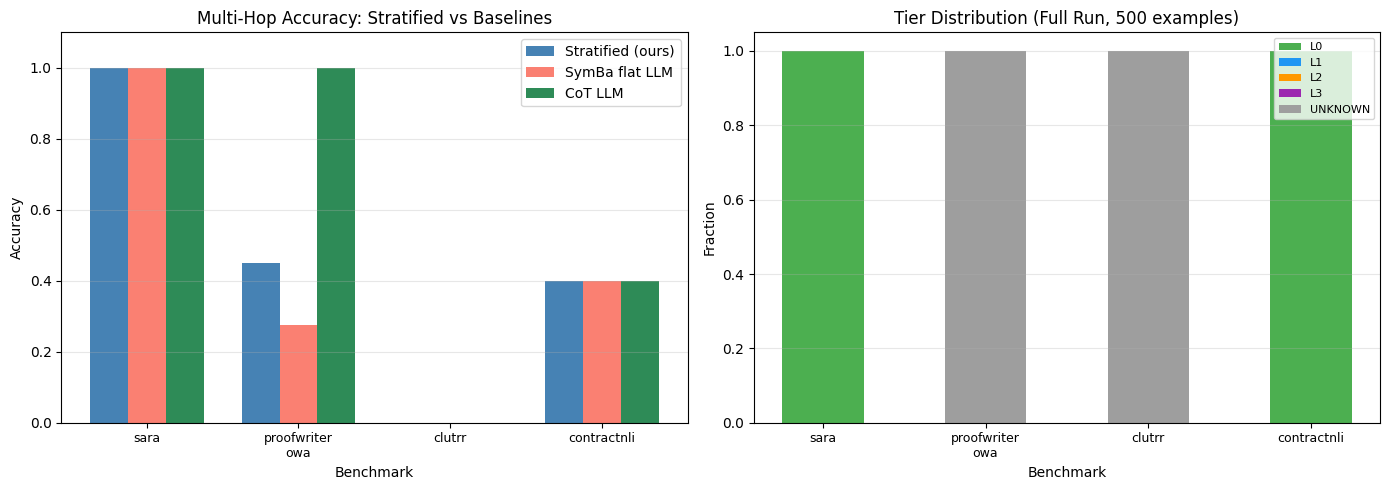

Saved: results_overview.png

=== Overall Summary (500 examples) ===
  Stratified pipeline accuracy: 0.320
  SymBa flat LLM accuracy:      0.250
  CoT LLM accuracy:             0.540
  Total cost (USD):             $0.0000


In [10]:
benchmarks = ["sara", "proofwriter_owa", "clutrr", "contractnli"]
acc_strat  = [agg[bm].get("accuracy_stratified", 0) for bm in benchmarks]
acc_symba  = [agg[bm].get("accuracy_symba", 0) for bm in benchmarks]
acc_cot    = [agg[bm].get("accuracy_cot", 0) for bm in benchmarks]

x = np.arange(len(benchmarks))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Accuracy comparison ---
ax = axes[0]
ax.bar(x - width, acc_strat, width, label="Stratified (ours)", color="steelblue")
ax.bar(x,          acc_symba, width, label="SymBa flat LLM",    color="salmon")
ax.bar(x + width,  acc_cot,   width, label="CoT LLM",           color="seagreen")
ax.set_xlabel("Benchmark")
ax.set_ylabel("Accuracy")
ax.set_title("Multi-Hop Accuracy: Stratified vs Baselines")
ax.set_xticks(x)
ax.set_xticklabels([b.replace("_", "\n") for b in benchmarks], fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# --- Right: Tier distribution (full run) ---
ax2 = axes[1]
tier_keys = ["l0", "l1", "l2", "l3", "unknown"]
tier_colors = ["#4CAF50", "#2196F3", "#FF9800", "#9C27B0", "#9E9E9E"]
bottoms = np.zeros(len(benchmarks))
for tk, tc in zip(tier_keys, tier_colors):
    vals = [agg[bm].get("tier_distribution", {}).get(tk, 0) for bm in benchmarks]
    ax2.bar(x, vals, width=0.5, bottom=bottoms, label=tk.upper(), color=tc)
    bottoms += np.array(vals)
ax2.set_xlabel("Benchmark")
ax2.set_ylabel("Fraction")
ax2.set_title("Tier Distribution (Full Run, 500 examples)")
ax2.set_xticks(x)
ax2.set_xticklabels([b.replace("_", "\n") for b in benchmarks], fontsize=9)
ax2.set_ylim(0, 1.05)
ax2.legend(loc="upper right", fontsize=8)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: results_overview.png")

# --- Print overall summary ---
overall = agg.get("overall", {})
print("\n=== Overall Summary (500 examples) ===")
print(f"  Stratified pipeline accuracy: {overall.get('accuracy_stratified', 0):.3f}")
print(f"  SymBa flat LLM accuracy:      {overall.get('accuracy_symba', 0):.3f}")
print(f"  CoT LLM accuracy:             {overall.get('accuracy_cot', 0):.3f}")
print(f"  Total cost (USD):             ${data['metadata']['total_cost_usd']:.4f}")